# 1. What is a Machine Learning Workflow?

A Machine Learning Workflow is the sequence of steps followed to build
a Machine Learning system.

A typical Machine Learning workflow looks like:

    Problem Definition
            ↓
    Data Collection
            ↓
    Data Understanding
            ↓
    Exploratory Data Analysis
            ↓
    Data Preprocessing
            ↓
    Feature Engineering
            ↓
    Train-Test Split
            ↓
    Model Selection
            ↓
    Model Training
            ↓
    Model Evaluation
            ↓
    Hyperparameter Tuning
            ↓
    Final Model
            ↓
    Model Saving
            ↓
    Deployment
            ↓
    Monitoring

Each step is important.

A good Machine Learning model cannot compensate for:

- Poor quality data
- Data leakage
- Incorrect preprocessing
- Wrong evaluation metrics
- Poor problem definition

In this notebook, we will follow this workflow using a
Customer Churn Prediction problem.

# 2. Problem Definition

The first step of a Machine Learning project is to clearly define
the problem.

Before writing any Machine Learning code, we should answer:

1. What problem are we trying to solve?
2. What is the input?
3. What should the model predict?
4. Is it a classification or regression problem?
5. How will we measure the model's performance?

## Problem Statement

A company wants to predict whether a customer will leave its service.

This is known as **Customer Churn Prediction**.

Our dataset contains information about customers such as:

- Region
- Signup date
- Subscription tier
- Number of orders
- Total amount spent

We will use this information to predict whether a customer has churned.

## Target Variable

The target variable is:

    churned

It contains two possible values:

- `False` → Customer did not churn
- `True` → Customer churned

Therefore, this is a **Binary Classification** problem.

## Machine Learning Objective

Our objective is:

    Customer Information
            ↓
    Machine Learning Model
            ↓
    Churn Prediction

# 3. Define the ML Problem Using the Dataset

Before building the model, we should identify the features and target.

## Features

Features are the input variables used by the Machine Learning model.

Potential features in our dataset include:

- `region`
- `signup_date`
- `subscription_tier`
- `orders_count`
- `total_spent_usd`

## Target

The target is the value that we want to predict:

    churned

## Columns That Should Not Be Used Directly

Some columns are not useful as predictive features.

For example:

- `customer_id` → Identifier, not meaningful customer behavior
- `name` → Personal identifier and not useful for this prediction

These columns should normally be removed before model training.

The `signup_date` column may contain useful information, but instead
of giving the raw date directly to most ML models, we can extract
useful features such as:

- Signup year
- Signup month
- Signup day
- Customer tenure

# 4. Data Collection

Data Collection is the process of obtaining the data required
to solve the Machine Learning problem.

Data can come from many sources, such as:

- Databases
- CSV files
- Excel files
- APIs
- Websites
- Sensors
- Applications
- Company internal systems

The quality of the collected data has a major impact on the
performance of the final Machine Learning model.

For this notebook, our customer data is provided directly as
a Python dictionary and converted into a pandas DataFrame.

In a real-world project, this data could come from a database
or a CSV file.

In [296]:
# Import pandas
import pandas as pd

# Create the customer churn dataset
data = {
    "customer_id": list(range(101, 151)),

    "name": [
        "Sarah Jenkins", "Marcus Chen", "Elena Rostova", "Devon Vance", "Aisha Patel",
        "Liam O'Connor", "Sofia Reyes", "Kenji Sato", "Maya Lin", "Lucas Becker",
        "Amara Okafor", "Mateo Silva", "Chloe Dubois", "Noah Kim", "Zara Al-Mansoor",
        "Ethan Wright", "Fatima Zahra", "Oliver Hansen", "Priya Sharma", "Gabriel Santos",
        "Hannah Schmidt", "Julian Rossi", "Ananya Iyer", "Dominic Cruz", "Leila Haddad",
        "Sebastian Meyer", "Nia Johnson", "Kaito Tanaka", "Camila Fernandez", "Owen Davis",
        "Ingrid Larsen", "Tariq Mansour", "Freja Nielsen", "Rohan Mehta", "Valeria Gomez",
        "Felix Laurent", "Zoe Mitchell", "Dante Moretti", "Yuki Takahashi", "Harper Clark",
        "Karim Benzema", "Siddharth Nair", "Elise Fontaine", "Leonidas Thorne", "Amina Diallo",
        "Jonas Lindqvist", "Beatriz Costa", "Arjun Kapoor", "Mei-Ling Wang", "Callum Scott",
    ],

    "region": [
        "North", "West", "East", "South", "West",
        "North", "South", "East", "West", "North",
        "South", "East", "North", "West", "South",
        "East", "North", "West", "South", "East",
        "North", "South", "West", "East", "North",
        "South", "West", "East", "North", "South",
        "East", "West", "North", "South", "West",
        "East", "North", "South", "East", "West",
        "North", "South", "East", "West", "North",
        "South", "East", "North", "West", "South",
    ],

    "signup_date": pd.to_datetime([
        "2026-01-14", "2026-02-03", "2026-03-21", "2025-11-19", "2026-04-05",
        "2025-12-30", "2026-05-12", "2026-02-18", "2026-03-10", "2026-06-01",
        "2025-10-15", "2026-04-22", "2026-01-29", "2025-11-04", "2026-05-30",
        "2026-02-11", "2025-09-18", "2026-03-05", "2025-12-14", "2026-04-18",
        "2026-01-08", "2025-10-29", "2026-05-02", "2026-02-24", "2025-11-30",
        "2026-03-15", "2026-01-22", "2025-12-05", "2026-04-28", "2026-06-10",
        "2025-10-02", "2026-02-14", "2026-03-30", "2025-11-12", "2026-05-19",
        "2026-01-19", "2026-04-09", "2025-12-22", "2026-03-01", "2026-05-25",
        "2025-10-20", "2026-02-27", "2026-04-14", "2025-11-08", "2026-06-05",
        "2026-01-03", "2026-03-18", "2025-12-11", "2026-04-30", "2026-02-07",
    ]),

    "subscription_tier": [
        "Premium", "Free", "Free", "Enterprise", "Premium",
        "Free", "Enterprise", "Premium", "Free", "Premium",
        "Enterprise", "Free", "Free", "Enterprise", "Premium",
        "Free", "Enterprise", "Premium", "Free", "Enterprise",
        "Free", "Premium", "Free", "Enterprise", "Free",
        "Premium", "Free", "Enterprise", "Premium", "Free",
        "Enterprise", "Premium", "Free", "Enterprise", "Free",
        "Premium", "Free", "Enterprise", "Premium", "Free",
        "Enterprise", "Premium", "Free", "Enterprise", "Free",
        "Premium", "Free", "Enterprise", "Premium", "Free",
    ],

    "orders_count": [
        12, 3, 0, 45, 18,
        5, 29, 14, 0, 8,
        52, 2, 0, 38, 16,
        1, 61, 21, 0, 44,
        4, 15, 0, 39, 2,
        22, 0, 50, 19, 3,
        48, 11, 0, 57, 1,
        25, 0, 41, 13, 2,
        64, 17, 0, 46, 3,
        20, 0, 53, 15, 4,
    ],

    "total_spent_usd": [
        429.50, 89.99, 0.00, 1240.25, 612.00,
        135.40, 890.75, 495.10, 0.00, 280.60,
        1590.40, 45.00, 0.00, 1120.00, 540.25,
        19.99, 1820.50, 710.00, 0.00, 1345.80,
        98.50, 480.20, 0.00, 1190.00, 42.10,
        745.60, 0.00, 1480.90, 625.30, 74.50,
        1410.75, 360.00, 0.00, 1730.20, 24.99,
        820.15, 0.00, 1260.40, 430.80, 55.00,
        1950.00, 560.70, 0.00, 1380.50, 68.20,
        690.40, 0.00, 1620.10, 510.90, 88.00,
    ],

    "churned": [
        False, False, True, False, False,
        True, False, False, True, False,
        False, False, True, False, False,
        False, False, False, True, False,
        False, False, True, False, True,
        False, True, False, False, False,
        False, False, True, False, True,
        False, True, False, False, False,
        False, False, True, False, True,
        False, True, False, False, False,
    ],
}

# Convert the dictionary into a DataFrame
df = pd.DataFrame(data)

# Display the dataset
df

,customer_id,name,region,signup_date,subscription_tier,orders_count,total_spent_usd,churned
0,101,Sarah Jenkins,North,2026-01-14,Premium,12,429.50,False
1,102,Marcus Chen,West,2026-02-03,Free,3,89.99,False
2,103,Elena Rostova,East,2026-03-21,Free,0,0.00,True
3,104,Devon Vance,South,2025-11-19,Enterprise,45,1240.25,False
4,105,Aisha Patel,West,2026-04-05,Premium,18,612.00,False
5,106,Liam O'Connor,North,2025-12-30,Free,5,135.40,True
6,107,Sofia Reyes,South,2026-05-12,Enterprise,29,890.75,False
7,108,Kenji Sato,East,2026-02-18,Premium,14,495.10,False
8,109,Maya Lin,West,2026-03-10,Free,0,0.00,True
9,110,Lucas Becker,North,2026-06-01,Premium,8,280.60,False


# 5. Data Understanding

After collecting the data, the next step is to understand
what the dataset contains.

We should identify:

- Number of rows
- Number of columns
- Feature names
- Data types
- Numerical features
- Categorical features
- Target variable

This step gives us a basic understanding of the data before
performing detailed Exploratory Data Analysis.

In [297]:
# Check the number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 50
Number of columns: 8


In [298]:
# Display all column names
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['customer_id', 'name', 'region', 'signup_date', 'subscription_tier', 'orders_count', 'total_spent_usd', 'churned']


In [299]:
# Display all column names
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['customer_id', 'name', 'region', 'signup_date', 'subscription_tier', 'orders_count', 'total_spent_usd', 'churned']


# 6. Identify Feature Types

Machine Learning datasets usually contain different types of
features.

## Numerical Features

Numerical features contain numbers.

In our dataset:

- `orders_count`
- `total_spent_usd`

## Categorical Features

Categorical features contain groups or categories.

In our dataset:

- `region`
- `subscription_tier`

## Date Feature

Our dataset contains:

- `signup_date`

Dates can contain useful information, but raw dates are usually
transformed into meaningful numerical features.

## Identifier Columns

Our dataset also contains:

- `customer_id`
- `name`

These are identifiers and should generally not be used directly
as predictive features.

In [300]:
# Define the different types of columns

numerical_features = [
    "orders_count",
    "total_spent_usd"
]

categorical_features = [
    "region",
    "subscription_tier"
]

date_features = [
    "signup_date"
]

identifier_features = [
    "customer_id",
    "name"
]

target = "churned"

# Display the groups
print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)
print("Date Features:", date_features)
print("Identifier Features:", identifier_features)
print("Target:", target)

Numerical Features: ['orders_count', 'total_spent_usd']
Categorical Features: ['region', 'subscription_tier']
Date Features: ['signup_date']
Identifier Features: ['customer_id', 'name']
Target: churned


# 7. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is the process of examining the dataset
to discover patterns, problems, and relationships.

EDA helps us answer questions such as:

- Are there missing values?
- Are there duplicate records?
- What is the distribution of numerical features?
- What categories exist?
- How is the target distributed?
- Are there outliers?
- Which features may be related to the target?

EDA should be performed before building the Machine Learning model.

The goal is not simply to create charts.

The goal is to understand the data and make better decisions
about preprocessing and model development.

## 8. Dataset Shape

The `shape` attribute returns the dimensions of the DataFrame.

It returns:

    (number of rows, number of columns)

In our dataset:

- Each row represents a customer.
- Each column represents a feature or variable.

In [301]:
# Check the shape of the dataset
df.shape

(50, 8)

## 9. Viewing the Dataset

Before analyzing the dataset, we should inspect the actual
records.

Pandas provides:

- `head()` → First rows
- `tail()` → Last rows
- `sample()` → Random rows

These functions provide a quick overview of the data.

In [302]:
# Display the first 5 rows
df.head()

,customer_id,name,region,signup_date,subscription_tier,orders_count,total_spent_usd,churned
0,101,Sarah Jenkins,North,2026-01-14,Premium,12,429.50,False
1,102,Marcus Chen,West,2026-02-03,Free,3,89.99,False
2,103,Elena Rostova,East,2026-03-21,Free,0,0.00,True
3,104,Devon Vance,South,2025-11-19,Enterprise,45,1240.25,False
4,105,Aisha Patel,West,2026-04-05,Premium,18,612.00,False


In [303]:
# Display the last 5 rows
df.tail()

,customer_id,name,region,signup_date,subscription_tier,orders_count,total_spent_usd,churned
45,146,Jonas Lindqvist,South,2026-01-03,Premium,20,690.4,False
46,147,Beatriz Costa,East,2026-03-18,Free,0,0.0,True
47,148,Arjun Kapoor,North,2025-12-11,Enterprise,53,1620.1,False
48,149,Mei-Ling Wang,West,2026-04-30,Premium,15,510.9,False
49,150,Callum Scott,South,2026-02-07,Free,4,88.0,False


In [304]:
# Display 3 random rows
df.sample(3)

,customer_id,name,region,signup_date,subscription_tier,orders_count,total_spent_usd,churned
10,111,Amara Okafor,South,2025-10-15,Enterprise,52,1590.4,False
21,122,Julian Rossi,South,2025-10-29,Premium,15,480.2,False
49,150,Callum Scott,South,2026-02-07,Free,4,88.0,False


## 10.1 Missing Values

Missing values occur when information is unavailable for
one or more observations.

Missing data can cause problems during model training.

Common techniques for handling missing values include:

- Removing rows
- Removing columns
- Filling with mean
- Filling with median
- Filling with mode
- Advanced imputation

We should first identify missing values before deciding
how to handle them.

In [305]:
# Count missing values in each column
df.isnull().sum()

customer_id          0
name                 0
region               0
signup_date          0
subscription_tier    0
orders_count         0
total_spent_usd      0
churned              0
dtype: int64

In [306]:
# Check whether any missing value exists
df.isnull().any().any()

np.False_

## 10.2 Duplicate Records

Duplicate records are rows that appear more than once.

Duplicates can affect model training because the same observation
may receive more importance than it should.

Therefore, we should identify duplicate rows before continuing
with the Machine Learning workflow.

In [307]:
# Count duplicate rows
df.duplicated().sum()

np.int64(0)

In [308]:
# Display duplicate rows
df[df.duplicated()]

,customer_id,name,region,signup_date,subscription_tier,orders_count,total_spent_usd,churned


## 10.3 Statistical Summary

Statistical summaries help us understand numerical features.

The `describe()` method provides:

- Count
- Mean
- Standard deviation
- Minimum
- 25th percentile
- Median
- 75th percentile
- Maximum

This gives us a quick understanding of the range and distribution
of numerical variables.

In [309]:
# Generate statistical summary for numerical features
df[numerical_features].describe()

,orders_count,total_spent_usd
count,50.000000,50.00000
mean,18.860000,581.27440
std,19.991845,603.04645
min,0.000000,0.00000
25%,2.000000,42.82500
50%,13.500000,455.50000
75%,35.750000,1062.68750
max,64.000000,1950.00000


## 10.4 Categorical Feature Analysis

Categorical features contain a fixed number of categories.

For our dataset, the main categorical features are:

- `region`
- `subscription_tier`

We can use `unique()` to find the available categories and
`value_counts()` to count how frequently each category occurs.

In [310]:
# Display unique regions
df["region"].unique()

<StringArray>
['North', 'West', 'East', 'South']
Length: 4, dtype: str

In [311]:
# Count customers in each region
df["region"].value_counts()

region
North    13
South    13
West     12
East     12
Name: count, dtype: int64

In [312]:
# Display unique subscription tiers
df["subscription_tier"].unique()

<StringArray>
['Premium', 'Free', 'Enterprise']
Length: 3, dtype: str

In [313]:
# Count customers in each subscription tier
df["subscription_tier"].value_counts()

subscription_tier
Free          21
Premium       15
Enterprise    14
Name: count, dtype: int64

## 10.5 Target Variable Analysis

The target variable is the variable that the Machine Learning
model is expected to predict.

For our problem:

    Target = churned

The target has two classes:

- `False` → Customer did not churn
- `True` → Customer churned

Because there are two classes, this is a binary classification problem.

We should check the distribution of these two classes before
training the model.

In [314]:
# Count the number of customers in each target class
df["churned"].value_counts()

churned
False    36
True     14
Name: count, dtype: int64

In [315]:
# Calculate the churn rate
churn_rate = df["churned"].mean() * 100

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 28.00%


## 10.6 Target Distribution

Visualization helps us understand the distribution of the target.

A bar chart can show how many customers:

- Churned
- Did not churn

This is particularly important when checking for class imbalance.

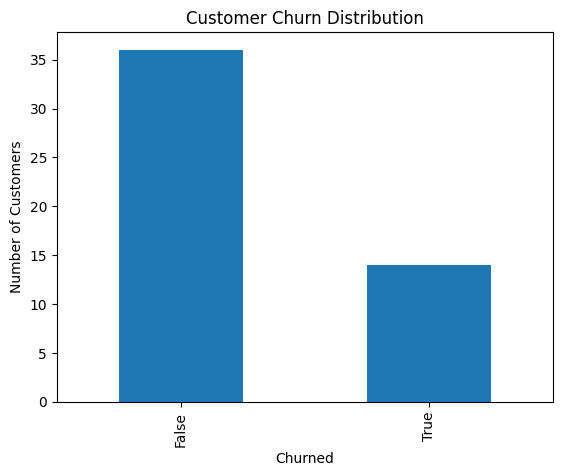

In [316]:
# Import matplotlib
import matplotlib.pyplot as plt

# Count target classes
churn_counts = df["churned"].value_counts()

# Create a bar chart
churn_counts.plot(kind="bar")

# Add labels
plt.title("Customer Churn Distribution")
plt.xlabel("Churned")
plt.ylabel("Number of Customers")

plt.show()

## 10.7 EDA Observation

From the initial EDA, we can now understand:

- The size of the dataset
- The available features
- The data types
- Whether missing values exist
- Whether duplicate records exist
- The distribution of numerical variables
- The distribution of categorical variables
- The distribution of the target variable

EDA gives us the information required for the next stage
of the workflow.

The next step is:

    Data Understanding
            ↓
          EDA
            ↓
    Data Preprocessing
            ↓
    Feature Engineering

# 11. Data Preprocessing

Data Preprocessing is the process of cleaning and transforming
raw data into a format that can be used by Machine Learning
algorithms.

Real-world datasets may contain:

- Missing values
- Duplicate records
- Irrelevant features
- Categorical values
- Date values
- Different numerical scales
- Incorrect data types

The main goal of preprocessing is to make the data
clean, consistent, and suitable for Machine Learning.

The preprocessing workflow is:

    Raw Data
        ↓
    Separate Features and Target
        ↓
    Remove Irrelevant Features
        ↓
    Handle Missing Values
        ↓
    Handle Duplicates
        ↓
    Transform Date Features
        ↓
    Encode Categorical Features
        ↓
    Scale Numerical Features
        ↓
    Preprocessed Data

## 11.1 Separating Features and Target

Before preprocessing, we separate the dataset into two parts:

### Features (X)

Features are the input variables used by the Machine Learning
model to make predictions.

For our customer churn problem, examples include:

- region
- signup_date
- subscription_tier
- orders_count
- total_spent_usd

### Target (y)

The target is the variable that we want the model to predict.

In our dataset:

    Target = churned

Therefore:

    X → Input features
    y → Target variable

The target should be kept separate from the input features.

In [317]:
# Separate features from the target variable

X = df.drop("churned", axis=1)

# Store the target variable separately
y = df["churned"]

# Display the features
X.head()

,customer_id,name,region,signup_date,subscription_tier,orders_count,total_spent_usd
0,101,Sarah Jenkins,North,2026-01-14,Premium,12,429.50
1,102,Marcus Chen,West,2026-02-03,Free,3,89.99
2,103,Elena Rostova,East,2026-03-21,Free,0,0.00
3,104,Devon Vance,South,2025-11-19,Enterprise,45,1240.25
4,105,Aisha Patel,West,2026-04-05,Premium,18,612.00


## 11.2 Removing Irrelevant Features

Not every column in a dataset is useful for prediction.

Our dataset contains:

- `customer_id`
- `name`

These columns are identifiers rather than meaningful
customer behavior.

### customer_id

The customer ID is simply an identifier.

For example:

    101, 102, 103, ...

The numerical value does not represent customer behavior.

### name

The customer's name is also not useful for predicting churn.

Therefore, these columns should be removed before
training the Machine Learning model.

Removing irrelevant features can:

- Reduce unnecessary information
- Simplify the dataset
- Reduce noise
- Make the model easier to understand

In [318]:
# Remove identifier columns

X = X.drop(
    ["customer_id", "name"],
    axis=1
)

# Display the remaining features
X.head()

,region,signup_date,subscription_tier,orders_count,total_spent_usd
0,North,2026-01-14,Premium,12,429.50
1,West,2026-02-03,Free,3,89.99
2,East,2026-03-21,Free,0,0.00
3,South,2025-11-19,Enterprise,45,1240.25
4,West,2026-04-05,Premium,18,612.00


## 11.3 Checking Missing Values

Missing values occur when information is not available for
one or more observations.

In a real-world dataset, missing values are very common.

For example, a customer may have:

- Missing region
- Missing subscription tier
- Missing number of orders
- Missing spending information

Missing values are usually represented as `NaN` in pandas.

Machine Learning algorithms may not be able to work directly
with missing values.

Therefore, we need to:

1. Detect missing values
2. Understand where they occur
3. Decide how to handle them

Common methods for handling missing values include:

- Removing rows
- Removing columns
- Filling numerical values with mean
- Filling numerical values with median
- Filling categorical values with mode
- Using advanced imputation techniques

In [319]:
# Create a copy of the original dataset
# We keep the original df unchanged
import numpy as np
df_ml = df.copy()

# Add some missing values intentionally for practice

# Missing numerical value
df_ml.loc[2, "orders_count"] = np.nan

# Missing numerical value
df_ml.loc[5, "total_spent_usd"] = np.nan

# Missing categorical value
df_ml.loc[4, "region"] = np.nan

# Missing categorical value
df_ml.loc[6, "subscription_tier"] = np.nan

# Display the modified dataset
df_ml

,customer_id,name,region,signup_date,subscription_tier,orders_count,total_spent_usd,churned
0,101,Sarah Jenkins,North,2026-01-14,Premium,12.0,429.50,False
1,102,Marcus Chen,West,2026-02-03,Free,3.0,89.99,False
2,103,Elena Rostova,East,2026-03-21,Free,NaN,0.00,True
3,104,Devon Vance,South,2025-11-19,Enterprise,45.0,1240.25,False
4,105,Aisha Patel,NaN,2026-04-05,Premium,18.0,612.00,False
5,106,Liam O'Connor,North,2025-12-30,Free,5.0,NaN,True
6,107,Sofia Reyes,South,2026-05-12,NaN,29.0,890.75,False
7,108,Kenji Sato,East,2026-02-18,Premium,14.0,495.10,False
8,109,Maya Lin,West,2026-03-10,Free,0.0,0.00,True
9,110,Lucas Becker,North,2026-06-01,Premium,8.0,280.60,False


In [320]:
# Count missing values in every column

df_ml.isnull().sum()

customer_id          0
name                 0
region               1
signup_date          0
subscription_tier    1
orders_count         1
total_spent_usd      1
churned              0
dtype: int64

In [321]:
# Find rows that contain at least one missing value

df_ml[df_ml.isnull().any(axis=1)]

,customer_id,name,region,signup_date,subscription_tier,orders_count,total_spent_usd,churned
2,103,Elena Rostova,East,2026-03-21,Free,NaN,0.00,True
4,105,Aisha Patel,NaN,2026-04-05,Premium,18.0,612.00,False
5,106,Liam O'Connor,North,2025-12-30,Free,5.0,NaN,True
6,107,Sofia Reyes,South,2026-05-12,NaN,29.0,890.75,False


### Checking Missing Value Percentage

The number of missing values alone may not be enough.

For a large dataset, it is useful to calculate the percentage
of missing values in each column.

Formula:

    Missing Percentage
    = (Missing Values / Total Values) × 100

In [322]:
# Calculate missing value percentage

missing_percentage = (
    df_ml.isnull().mean() * 100
)

missing_percentage

customer_id          0.0
name                 0.0
region               2.0
signup_date          0.0
subscription_tier    2.0
orders_count         2.0
total_spent_usd      2.0
churned              0.0
dtype: float64

## 11.4 Handling Missing Values

After detecting missing values, we need to decide how
to handle them.

The method depends on the type of feature.

### Numerical Features

For numerical features, common methods are:

- Mean
- Median

The median is often preferred when the data contains
outliers because it is less affected by extreme values.

### Categorical Features

For categorical features, we can use:

- Mode
- A new category such as `"Unknown"`

For this dataset, we will use:

- Median for numerical features
- Mode for categorical features

This allows us to keep all customer records instead
of deleting rows.    

In [323]:
# Check missing values in numerical columns

numerical_features = [
    "orders_count",
    "total_spent_usd"
]

df_ml[numerical_features].isnull().sum()

orders_count       1
total_spent_usd    1
dtype: int64

In [324]:
# Fill missing numerical values with the median

for column in numerical_features:
    df_ml[column] = df_ml[column].fillna(
        df_ml[column].median()
    )

# Check again
df_ml[numerical_features].isnull().sum()

orders_count       0
total_spent_usd    0
dtype: int64

### Why Median?

Suppose a feature contains:

    10, 12, 15, 18, 1000

The value `1000` is much larger than the other values.

The mean will be strongly affected by this extreme value,
while the median will remain more representative of the
typical observation.

Therefore, median imputation can be useful when numerical
data contains potential outliers.

In [325]:
# Check missing values in categorical columns

categorical_features = [
    "region",
    "subscription_tier"
]

df_ml[categorical_features].isnull().sum()

region               1
subscription_tier    1
dtype: int64

In [326]:
# Fill missing categorical values using the mode

for column in categorical_features:
    df_ml[column] = df_ml[column].fillna(
        df_ml[column].mode()[0]
    )

# Check again
df_ml[categorical_features].isnull().sum()

region               0
subscription_tier    0
dtype: int64

In [327]:
# Check all missing values after imputation

df_ml.isnull().sum()

customer_id          0
name                 0
region               0
signup_date          0
subscription_tier    0
orders_count         0
total_spent_usd      0
churned              0
dtype: int64

## 11.5 Checking Duplicate Records

A duplicate record is a row that contains the same information
as another row.

Duplicate records can create problems because the same
observation may be given extra importance during model training.

For example, if the same customer appears multiple times,
the Machine Learning model may treat those records as
different observations.

Therefore, duplicate records should be identified before
training the model.

In [328]:
# Create a duplicate record intentionally for practice

# Select one existing row
duplicate_row = df_ml.iloc[[1]]

# Add the duplicate row to the dataset
df_ml = pd.concat(
    [df_ml, duplicate_row],
    ignore_index=True
)

# Display the dataset
df_ml

,customer_id,name,region,signup_date,subscription_tier,orders_count,total_spent_usd,churned
0,101,Sarah Jenkins,North,2026-01-14,Premium,12.0,429.50,False
1,102,Marcus Chen,West,2026-02-03,Free,3.0,89.99,False
2,103,Elena Rostova,East,2026-03-21,Free,14.0,0.00,True
3,104,Devon Vance,South,2025-11-19,Enterprise,45.0,1240.25,False
4,105,Aisha Patel,North,2026-04-05,Premium,18.0,612.00,False
5,106,Liam O'Connor,North,2025-12-30,Free,5.0,480.20,True
6,107,Sofia Reyes,South,2026-05-12,Free,29.0,890.75,False
7,108,Kenji Sato,East,2026-02-18,Premium,14.0,495.10,False
8,109,Maya Lin,West,2026-03-10,Free,0.0,0.00,True
9,110,Lucas Becker,North,2026-06-01,Premium,8.0,280.60,False


In [329]:
# Count duplicate rows

df_ml.duplicated().sum()

np.int64(1)

### Understanding `duplicated()`

The `duplicated()` method checks whether a row has already
appeared earlier in the dataset.

It returns:

- `True` → Duplicate row
- `False` → Unique row

Using:

    df_ml.duplicated().sum()

gives us the total number of duplicate rows.

In [330]:
# Display all duplicate rows

df_ml[df_ml.duplicated()]

,customer_id,name,region,signup_date,subscription_tier,orders_count,total_spent_usd,churned
50,102,Marcus Chen,West,2026-02-03,Free,3.0,89.99,False


## 11.6 Removing Duplicate Records

Once duplicate records have been identified, we can remove them.

Pandas provides the `drop_duplicates()` method for this purpose.

By default, pandas keeps the first occurrence and removes
the subsequent duplicate records.

Therefore:

    Before removing duplicates → 9 rows

    After removing duplicates → 8 rows

In [331]:
# Remove duplicate records

df_ml = df_ml.drop_duplicates()

# Check the new shape
df_ml.shape

(50, 8)

In [332]:
# Verify that no duplicate rows remain

df_ml.duplicated().sum()

np.int64(0)

## 11.7 Verifying the Cleaned Dataset

After handling missing values and duplicate records,
we should verify that the dataset is clean.

We will check:

- Dataset shape
- Missing values
- Duplicate records
- Data types

This is an important habit in Machine Learning workflows.

After every major preprocessing operation, verify the result
instead of assuming that the operation worked correctly.

In [333]:
# Check the final shape

print("Dataset Shape:", df_ml.shape)

Dataset Shape: (50, 8)


In [334]:
# Check remaining missing values

print("Missing Values:")
print(df_ml.isnull().sum())

Missing Values:
customer_id          0
name                 0
region               0
signup_date          0
subscription_tier    0
orders_count         0
total_spent_usd      0
churned              0
dtype: int64


In [335]:
# Check data types

df_ml.dtypes

customer_id                   int64
name                            str
region                          str
signup_date          datetime64[us]
subscription_tier               str
orders_count                float64
total_spent_usd             float64
churned                        bool
dtype: object

## 11.8 Data Preprocessing Observation

We intentionally introduced missing values and a duplicate
record into the dataset to understand how they are handled.

We then:

- Detected missing values
- Calculated missing-value percentages
- Filled numerical missing values using the median
- Filled categorical missing values using the mode
- Detected duplicate records
- Removed duplicate records
- Verified the cleaned dataset

The dataset is now ready for the next preprocessing step.

The next step is:

    Date Feature Engineering

In [336]:
# Display the cleaned dataset

df_ml

,customer_id,name,region,signup_date,subscription_tier,orders_count,total_spent_usd,churned
0,101,Sarah Jenkins,North,2026-01-14,Premium,12.0,429.50,False
1,102,Marcus Chen,West,2026-02-03,Free,3.0,89.99,False
2,103,Elena Rostova,East,2026-03-21,Free,14.0,0.00,True
3,104,Devon Vance,South,2025-11-19,Enterprise,45.0,1240.25,False
4,105,Aisha Patel,North,2026-04-05,Premium,18.0,612.00,False
5,106,Liam O'Connor,North,2025-12-30,Free,5.0,480.20,True
6,107,Sofia Reyes,South,2026-05-12,Free,29.0,890.75,False
7,108,Kenji Sato,East,2026-02-18,Premium,14.0,495.10,False
8,109,Maya Lin,West,2026-03-10,Free,0.0,0.00,True
9,110,Lucas Becker,North,2026-06-01,Premium,8.0,280.60,False


## 11.9 Date Feature Engineering

Machine Learning algorithms generally work with numerical
features rather than raw date values.

For example:

    2026-01-14

is a date, but it can contain several useful pieces of
information such as:

- Year
- Month
- Day
- Day of week
- Customer tenure

Therefore, instead of directly using the raw `signup_date`,
we can extract useful information from it.

This process is called **Date Feature Engineering**.

For our customer churn problem, the date can help us
understand how long a customer has been associated with
the company.

In [337]:
# Check the signup_date column

df_ml["signup_date"]

0    2026-01-14
1    2026-02-03
2    2026-03-21
3    2025-11-19
4    2026-04-05
5    2025-12-30
6    2026-05-12
7    2026-02-18
8    2026-03-10
9    2026-06-01
10   2025-10-15
11   2026-04-22
12   2026-01-29
13   2025-11-04
14   2026-05-30
15   2026-02-11
16   2025-09-18
17   2026-03-05
18   2025-12-14
19   2026-04-18
20   2026-01-08
21   2025-10-29
22   2026-05-02
23   2026-02-24
24   2025-11-30
25   2026-03-15
26   2026-01-22
27   2025-12-05
28   2026-04-28
29   2026-06-10
30   2025-10-02
31   2026-02-14
32   2026-03-30
33   2025-11-12
34   2026-05-19
35   2026-01-19
36   2026-04-09
37   2025-12-22
38   2026-03-01
39   2026-05-25
40   2025-10-20
41   2026-02-27
42   2026-04-14
43   2025-11-08
44   2026-06-05
45   2026-01-03
46   2026-03-18
47   2025-12-11
48   2026-04-30
49   2026-02-07
Name: signup_date, dtype: datetime64[us]

## 11.10 Extracting Signup Year

The year tells us when the customer joined the company.

For example:

    2026-01-14 → 2026
    2025-11-19 → 2025

We can extract the year using the `.dt.year` attribute
provided by pandas.

In [338]:
# Extract the year from signup_date

df_ml["signup_year"] = df_ml["signup_date"].dt.year

# Display the result
df_ml[["signup_date", "signup_year"]]

,signup_date,signup_year
0,2026-01-14,2026
1,2026-02-03,2026
2,2026-03-21,2026
3,2025-11-19,2025
4,2026-04-05,2026
5,2025-12-30,2025
6,2026-05-12,2026
7,2026-02-18,2026
8,2026-03-10,2026
9,2026-06-01,2026


## 11.11 Extracting Signup Month

The month represents the month in which the customer
signed up.

Pandas represents months using numbers:

    January   → 1
    February  → 2
    March     → 3
    ...
    December  → 12

The month can sometimes contain useful seasonal information.

In [339]:
# Extract the month from signup_date

df_ml["signup_month"] = df_ml["signup_date"].dt.month

# Display the result
df_ml[["signup_date", "signup_month"]]

,signup_date,signup_month
0,2026-01-14,1
1,2026-02-03,2
2,2026-03-21,3
3,2025-11-19,11
4,2026-04-05,4
5,2025-12-30,12
6,2026-05-12,5
7,2026-02-18,2
8,2026-03-10,3
9,2026-06-01,6


## 11.12 Extracting Signup Day

We can also extract the day of the month from the signup date.

For example:

    2026-01-14 → 14
    2026-02-03 → 3

The extracted day becomes a numerical feature.

In [340]:
# Extract the day of the month

df_ml["signup_day"] = df_ml["signup_date"].dt.day

# Display the result
df_ml[["signup_date", "signup_day"]]

,signup_date,signup_day
0,2026-01-14,14
1,2026-02-03,3
2,2026-03-21,21
3,2025-11-19,19
4,2026-04-05,5
5,2025-12-30,30
6,2026-05-12,12
7,2026-02-18,18
8,2026-03-10,10
9,2026-06-01,1


## 11.13 Extracting Day of Week

We can also determine which day of the week the customer
signed up.

Pandas represents the days as:

    Monday    → 0
    Tuesday   → 1
    Wednesday → 2
    Thursday  → 3
    Friday    → 4
    Saturday  → 5
    Sunday    → 6

This converts the day of the week into a numerical feature.

In [341]:
# Extract the day of the week

df_ml["signup_day_of_week"] = df_ml["signup_date"].dt.dayofweek

# Display the result
df_ml[["signup_date", "signup_day_of_week"]]

,signup_date,signup_day_of_week
0,2026-01-14,2
1,2026-02-03,1
2,2026-03-21,5
3,2025-11-19,2
4,2026-04-05,6
5,2025-12-30,1
6,2026-05-12,1
7,2026-02-18,2
8,2026-03-10,1
9,2026-06-01,0


## 11.14 Creating Customer Tenure

Customer tenure represents how long a customer has been
associated with the company.

The basic formula is:

    Customer Tenure
    = Reference Date - Signup Date

For this notebook, we will use:

    Reference Date = 2026-06-30

We will calculate tenure in days.

For example, if a customer signed up on:

    2026-01-14

and the reference date is:

    2026-06-30

then the tenure is the number of days between these dates.

Customer tenure can be more useful to a Machine Learning model
than the original date itself.

In [342]:
# Define a reference date after all signup dates
reference_date = pd.Timestamp("2026-06-30")
# Calculate customer tenure in days
df_ml["customer_tenure_days"] = (
reference_date - df_ml["signup_date"]
).dt.days
# Display signup date and calculated tenure
df_ml[
[
"signup_date",
"customer_tenure_days"
]
]


,signup_date,customer_tenure_days
0,2026-01-14,167
1,2026-02-03,147
2,2026-03-21,101
3,2025-11-19,223
4,2026-04-05,86
5,2025-12-30,182
6,2026-05-12,49
7,2026-02-18,132
8,2026-03-10,112
9,2026-06-01,29


## 11.15 Checking the New Date Features

We have now extracted several useful features from
`signup_date`.

The new features are:

- `signup_year`
- `signup_month`
- `signup_day`
- `signup_day_of_week`
- `customer_tenure_days`

These features represent different aspects of the
original signup date in numerical form.

In [343]:
# Display all newly created date features

date_features = [
    "signup_year",
    "signup_month",
    "signup_day",
    "signup_day_of_week",
    "customer_tenure_days"
]

df_ml[date_features]

,signup_year,signup_month,signup_day,signup_day_of_week,customer_tenure_days
0,2026,1,14,2,167
1,2026,2,3,1,147
2,2026,3,21,5,101
3,2025,11,19,2,223
4,2026,4,5,6,86
5,2025,12,30,1,182
6,2026,5,12,1,49
7,2026,2,18,2,132
8,2026,3,10,1,112
9,2026,6,1,0,29


## 11.16 Removing the Original Date Column

After extracting the useful information from `signup_date`,
we no longer need the original date column for our basic model.

We can remove it because:

- The useful date information has already been extracted.
- Most traditional ML algorithms work with numerical data.
- Keeping unnecessary columns makes the feature set more complex.

Therefore, we remove `signup_date`.

In [344]:
# Remove the original signup_date column

df_ml = df_ml.drop("signup_date", axis=1)

# Display the updated dataset
df_ml.head()

,customer_id,name,region,subscription_tier,orders_count,total_spent_usd,churned,signup_year,signup_month,signup_day,signup_day_of_week,customer_tenure_days
0,101,Sarah Jenkins,North,Premium,12.0,429.50,False,2026,1,14,2,167
1,102,Marcus Chen,West,Free,3.0,89.99,False,2026,2,3,1,147
2,103,Elena Rostova,East,Free,14.0,0.00,True,2026,3,21,5,101
3,104,Devon Vance,South,Enterprise,45.0,1240.25,False,2025,11,19,2,223
4,105,Aisha Patel,North,Premium,18.0,612.00,False,2026,4,5,6,86


## 11.17 Categorical Feature Encoding

Our dataset still contains categorical features:

- `region`
- `subscription_tier`

For example:

    region

    North
    South
    East
    West

Machine Learning algorithms generally require numerical
input rather than text categories.

Therefore, we need to convert categorical values into
numerical representations.

This process is called **Categorical Encoding**.

Common encoding techniques include:

1. Label Encoding
2. Ordinal Encoding
3. One-Hot Encoding

The correct technique depends on the type of categorical
variable.

In [345]:
# Display the categorical features

df_ml[[
    "region",
    "subscription_tier"
]]

,region,subscription_tier
0,North,Premium
1,West,Free
2,East,Free
3,South,Enterprise
4,North,Premium
5,North,Free
6,South,Free
7,East,Premium
8,West,Free
9,North,Premium


## 11.18 One-Hot Encoding

One-Hot Encoding converts each category into a separate
binary feature.

For example:

    region

    North
    South
    East
    West

can become:

    region_North
    region_South
    region_East
    region_West

For a customer from North:

    region_North = 1
    region_South = 0
    region_East  = 0
    region_West  = 0

One-Hot Encoding is suitable for nominal categories where
there is no natural order between the categories.

For example:

    North < South < East < West

does not have a meaningful numerical ordering.

Therefore, One-Hot Encoding is appropriate for our
`region` feature.

## 11.19 Applying One-Hot Encoding

Pandas provides the `get_dummies()` function for performing
One-Hot Encoding.

We will encode:

- `region`
- `subscription_tier`

We will use:

    drop_first=True

This removes one category from each categorical feature.

The remaining categories can still represent the original
information without creating unnecessary redundant columns.

In [346]:
# Apply One-Hot Encoding
df_encoded = pd.get_dummies(
    df_ml,
    columns=categorical_features,
    drop_first=True
)

# Display the encoded dataset
df_encoded

,customer_id,name,orders_count,total_spent_usd,churned,signup_year,signup_month,signup_day,signup_day_of_week,customer_tenure_days,region_North,region_South,region_West,subscription_tier_Free,subscription_tier_Premium
0,101,Sarah Jenkins,12.0,429.50,False,2026,1,14,2,167,True,False,False,False,True
1,102,Marcus Chen,3.0,89.99,False,2026,2,3,1,147,False,False,True,True,False
2,103,Elena Rostova,14.0,0.00,True,2026,3,21,5,101,False,False,False,True,False
3,104,Devon Vance,45.0,1240.25,False,2025,11,19,2,223,False,True,False,False,False
4,105,Aisha Patel,18.0,612.00,False,2026,4,5,6,86,True,False,False,False,True
5,106,Liam O'Connor,5.0,480.20,True,2025,12,30,1,182,True,False,False,True,False
6,107,Sofia Reyes,29.0,890.75,False,2026,5,12,1,49,False,True,False,True,False
7,108,Kenji Sato,14.0,495.10,False,2026,2,18,2,132,False,False,False,False,True
8,109,Maya Lin,0.0,0.00,True,2026,3,10,1,112,False,False,True,True,False
9,110,Lucas Becker,8.0,280.60,False,2026,6,1,0,29,True,False,False,False,True


## 11.20 Checking the Encoded Columns

After One-Hot Encoding, the original categorical columns
are replaced by numerical indicator columns.

For example:

    region
        ↓
    region_North
    region_South
    region_West

and:

    subscription_tier
        ↓
    subscription_tier_Free
    subscription_tier_Premium

One category from each feature is used as the reference
category because we used `drop_first=True`.

In [347]:
# Display the column names after encoding

df_encoded.columns.tolist()

['customer_id',
 'name',
 'orders_count',
 'total_spent_usd',
 'churned',
 'signup_year',
 'signup_month',
 'signup_day',
 'signup_day_of_week',
 'customer_tenure_days',
 'region_North',
 'region_South',
 'region_West',
 'subscription_tier_Free',
 'subscription_tier_Premium']

## 11.21 Checking Data Types After Encoding

After preprocessing, we should check the data types again.

Our Machine Learning features should now mainly contain
numerical values.

This is an important verification step before moving
towards model training.

In [348]:
# Check data types after encoding

df_encoded.dtypes

customer_id                    int64
name                             str
orders_count                 float64
total_spent_usd              float64
churned                         bool
signup_year                    int32
signup_month                   int32
signup_day                     int32
signup_day_of_week             int32
customer_tenure_days           int64
region_North                    bool
region_South                    bool
region_West                     bool
subscription_tier_Free          bool
subscription_tier_Premium       bool
dtype: object

## 11.22 Converting Boolean Values to Integers

Depending on the pandas version, One-Hot Encoding may create
Boolean columns.

Boolean values are:

    True
    False

For a Machine Learning feature matrix, we can explicitly
convert them to:

    True  → 1
    False → 0

This gives us a completely numerical representation.

In [349]:
# Find Boolean columns

bool_columns = df_encoded.select_dtypes(
    include="bool"
).columns

# Convert Boolean columns to integers
df_encoded[bool_columns] = df_encoded[bool_columns].astype(int)

# Check the data types again
df_encoded.dtypes

customer_id                    int64
name                             str
orders_count                 float64
total_spent_usd              float64
churned                        int64
signup_year                    int32
signup_month                   int32
signup_day                     int32
signup_day_of_week             int32
customer_tenure_days           int64
region_North                   int64
region_South                   int64
region_West                    int64
subscription_tier_Free         int64
subscription_tier_Premium      int64
dtype: object

In [350]:
df_encoded.head()

,customer_id,name,orders_count,total_spent_usd,churned,signup_year,signup_month,signup_day,signup_day_of_week,customer_tenure_days,region_North,region_South,region_West,subscription_tier_Free,subscription_tier_Premium
0,101,Sarah Jenkins,12.0,429.50,0,2026,1,14,2,167,1,0,0,0,1
1,102,Marcus Chen,3.0,89.99,0,2026,2,3,1,147,0,0,1,1,0
2,103,Elena Rostova,14.0,0.00,1,2026,3,21,5,101,0,0,0,1,0
3,104,Devon Vance,45.0,1240.25,0,2025,11,19,2,223,0,1,0,0,0
4,105,Aisha Patel,18.0,612.00,0,2026,4,5,6,86,1,0,0,0,1


## 11.23 Separating Features and Target Again

After completing the preprocessing transformations,
we need to separate the features and target again.

Our target is:

    churned

Everything else that will be used for prediction belongs
to `X`.

Therefore:

    X → Input features
    y → Target

In [351]:
# Separate the target from the processed dataset

X = df_encoded.drop("churned", axis=1)

# Store the target separately
y = df_encoded["churned"]

# Display the features
X.head()

,customer_id,name,orders_count,total_spent_usd,signup_year,signup_month,signup_day,signup_day_of_week,customer_tenure_days,region_North,region_South,region_West,subscription_tier_Free,subscription_tier_Premium
0,101,Sarah Jenkins,12.0,429.50,2026,1,14,2,167,1,0,0,0,1
1,102,Marcus Chen,3.0,89.99,2026,2,3,1,147,0,0,1,1,0
2,103,Elena Rostova,14.0,0.00,2026,3,21,5,101,0,0,0,1,0
3,104,Devon Vance,45.0,1240.25,2025,11,19,2,223,0,1,0,0,0
4,105,Aisha Patel,18.0,612.00,2026,4,5,6,86,1,0,0,0,1


In [352]:
# Display the target

y.head()

0    0
1    0
2    1
3    0
4    0
Name: churned, dtype: int64

## 11.24 Final Preprocessed Feature Set

Our raw customer dataset has now been transformed.

The original data contained:

- Customer ID
- Customer name
- Region
- Signup date
- Subscription tier
- Orders
- Total spending
- Churn status

After preprocessing:

- Identifier columns were removed.
- Missing values were handled.
- Duplicate records were removed.
- Date information was transformed.
- Categorical features were encoded.
- The target was separated from the features.

The resulting `X` contains features that can be passed
to a Machine Learning algorithm.

However, we have not yet performed feature scaling or
train-test splitting.

Those steps will come later in the workflow.

In [353]:
# Display the final feature matrix

X

,customer_id,name,orders_count,total_spent_usd,signup_year,signup_month,signup_day,signup_day_of_week,customer_tenure_days,region_North,region_South,region_West,subscription_tier_Free,subscription_tier_Premium
0,101,Sarah Jenkins,12.0,429.50,2026,1,14,2,167,1,0,0,0,1
1,102,Marcus Chen,3.0,89.99,2026,2,3,1,147,0,0,1,1,0
2,103,Elena Rostova,14.0,0.00,2026,3,21,5,101,0,0,0,1,0
3,104,Devon Vance,45.0,1240.25,2025,11,19,2,223,0,1,0,0,0
4,105,Aisha Patel,18.0,612.00,2026,4,5,6,86,1,0,0,0,1
5,106,Liam O'Connor,5.0,480.20,2025,12,30,1,182,1,0,0,1,0
6,107,Sofia Reyes,29.0,890.75,2026,5,12,1,49,0,1,0,1,0
7,108,Kenji Sato,14.0,495.10,2026,2,18,2,132,0,0,0,0,1
8,109,Maya Lin,0.0,0.00,2026,3,10,1,112,0,0,1,1,0
9,110,Lucas Becker,8.0,280.60,2026,6,1,0,29,1,0,0,0,1


In [354]:
# Display the target variable

y

0     0
1     0
2     1
3     0
4     0
5     1
6     0
7     0
8     1
9     0
10    0
11    0
12    1
13    0
14    0
15    0
16    0
17    0
18    1
19    0
20    0
21    0
22    1
23    0
24    1
25    0
26    1
27    0
28    0
29    0
30    0
31    0
32    1
33    0
34    1
35    0
36    1
37    0
38    0
39    0
40    0
41    0
42    1
43    0
44    1
45    0
46    1
47    0
48    0
49    0
Name: churned, dtype: int64

In [355]:
# Check the final shape of X and y

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50, 14)
y shape: (50,)


## 11.25 Data Preprocessing Observation

In this section, we transformed the raw dataset into a
Machine Learning-friendly representation.

We performed:

1. Missing value detection
2. Missing value handling
3. Duplicate detection
4. Duplicate removal
5. Date feature extraction
6. Customer tenure creation
7. Categorical feature encoding
8. Boolean-to-integer conversion
9. Feature-target separation

The data is now ready for the next stage of the workflow.

However, we should remember an important Machine Learning rule:

    Preprocessing should be learned from the training data,
    not from the test data.

Therefore, when we perform the actual Train-Test Split,
we will use tools such as:

- `SimpleImputer`
- `OneHotEncoder`
- `StandardScaler`
- `ColumnTransformer`
- `Pipeline`

This helps prevent **Data Leakage**.

The next major stage is:

    Feature Engineering

# 12. Feature Engineering

Feature Engineering is the process of creating, transforming,
or selecting features from existing data to improve the
performance of a Machine Learning model.

A feature is an input variable used by a Machine Learning
model.

For example, our original dataset contains:

- `orders_count`
- `total_spent_usd`
- `subscription_tier`
- `region`
- `signup_date`

We can create new features from these existing features.

For example:

    orders_count
          +
    total_spent_usd
          ↓
    average_order_value

Feature Engineering is important because good features can
help a Machine Learning model identify useful patterns in data.

The main Feature Engineering operations include:

- Creating new features
- Transforming existing features
- Combining features
- Extracting information
- Selecting useful features
- Removing unnecessary features

Feature Engineering should always be based on the problem
we are trying to solve.

## 12.1 Why Feature Engineering is Important

Machine Learning models learn patterns from the features
provided to them.

Sometimes the raw features do not directly represent the
pattern we want the model to learn.

For example:

    orders_count = 10
    total_spent_usd = 500

Instead of providing only these two values, we can create:

    average_order_value = 500 / 10
                         = 50

This new feature tells us how much the customer spends
per order.

A well-designed feature can make an important pattern
easier for the model to learn.

However, creating many unnecessary features is not always
better.

Too many irrelevant features can:

- Add noise
- Increase model complexity
- Increase training time
- Cause overfitting

Therefore, Feature Engineering should be meaningful
and problem-specific.

## 12.2 Create a Working Dataset

We will continue working with the customer churn dataset.

At this stage, we have:

    X → Processed features
    y → Target variable

We will temporarily combine them so that we can easily
demonstrate feature engineering.

Later, before model training, we will separate the target again.

In [356]:
# Create a copy of the processed dataset

feature_df = X.copy()

# Add the target for analysis
feature_df["churned"] = y

# Display the dataset
feature_df.head()

,customer_id,name,orders_count,total_spent_usd,signup_year,signup_month,signup_day,signup_day_of_week,customer_tenure_days,region_North,region_South,region_West,subscription_tier_Free,subscription_tier_Premium,churned
0,101,Sarah Jenkins,12.0,429.50,2026,1,14,2,167,1,0,0,0,1,0
1,102,Marcus Chen,3.0,89.99,2026,2,3,1,147,0,0,1,1,0,0
2,103,Elena Rostova,14.0,0.00,2026,3,21,5,101,0,0,0,1,0,1
3,104,Devon Vance,45.0,1240.25,2025,11,19,2,223,0,1,0,0,0,0
4,105,Aisha Patel,18.0,612.00,2026,4,5,6,86,1,0,0,0,1,0


## 12.3 Creating Average Order Value

One useful feature for customer behavior is:

    Average Order Value

It represents how much money a customer spends per order.

Formula:

    Average Order Value
    = Total Spent / Orders Count

For example:

    Total Spent = $500
    Orders = 10

    Average Order Value = 500 / 10
                        = $50

This can provide additional information about customer
purchasing behavior.

In [357]:
# Create Average Order Value

feature_df["average_order_value"] = (
    feature_df["total_spent_usd"] /
    feature_df["orders_count"]
)

# Display the result
feature_df[
    [
        "orders_count",
        "total_spent_usd",
        "average_order_value"
    ]
]

,orders_count,total_spent_usd,average_order_value
0,12.0,429.50,35.791667
1,3.0,89.99,29.996667
2,14.0,0.00,0.000000
3,45.0,1240.25,27.561111
4,18.0,612.00,34.000000
5,5.0,480.20,96.040000
6,29.0,890.75,30.715517
7,14.0,495.10,35.364286
8,0.0,0.00,NaN
9,8.0,280.60,35.075000


## 12.4 Handling Division by Zero

There is an important problem with our new feature.

Some customers may have:

    orders_count = 0

If we calculate:

    total_spent_usd / orders_count

we would divide by zero.

This can produce:

    inf

or an invalid value.

Our dataset contains a customer with zero orders.

Therefore, we need to handle this case.

A simple solution is to replace zero orders with `NaN`
before performing the division.

We can then replace the resulting missing value with `0`.

In this problem, if a customer has made zero orders,
their average order value can reasonably be represented
as zero.

In [358]:
# Replace zero orders with NaN temporarily
orders = feature_df["orders_count"].replace(0, np.nan)

# Calculate average order value
feature_df["average_order_value"] = (
    feature_df["total_spent_usd"] / orders
)

# Replace missing values with 0
feature_df["average_order_value"] = (
    feature_df["average_order_value"].fillna(0)
)

# Display the result
feature_df[
    [
        "orders_count",
        "total_spent_usd",
        "average_order_value"
    ]
]

,orders_count,total_spent_usd,average_order_value
0,12.0,429.50,35.791667
1,3.0,89.99,29.996667
2,14.0,0.00,0.000000
3,45.0,1240.25,27.561111
4,18.0,612.00,34.000000
5,5.0,480.20,96.040000
6,29.0,890.75,30.715517
7,14.0,495.10,35.364286
8,0.0,0.00,0.000000
9,8.0,280.60,35.075000


## 12.5 Creating Spending per Tenure Day

Another potentially useful feature is the amount a customer
spends relative to their tenure.

Formula:

    Spending Per Tenure Day
    = Total Spent / Customer Tenure

This can help compare customers who have been with the
company for different amounts of time.

For example:

    Customer A
    Total spent = $500
    Tenure = 100 days

    Spending per day = $5

This may provide a different perspective than total spending
alone.

In [359]:
# Calculate spending per tenure day

feature_df["spending_per_tenure_day"] = (
    feature_df["total_spent_usd"] /
    feature_df["customer_tenure_days"]
)

# Display the new feature
feature_df[
    [
        "total_spent_usd",
        "customer_tenure_days",
        "spending_per_tenure_day"
    ]
]

,total_spent_usd,customer_tenure_days,spending_per_tenure_day
0,429.50,167,2.571856
1,89.99,147,0.612177
2,0.00,101,0.000000
3,1240.25,223,5.561659
4,612.00,86,7.116279
5,480.20,182,2.638462
6,890.75,49,18.178571
7,495.10,132,3.750758
8,0.00,112,0.000000
9,280.60,29,9.675862


## 12.6 Checking the New Features

We have created two new behavioral features:

1. `average_order_value`
2. `spending_per_tenure_day`

These features were derived from existing information.

Feature Engineering does not necessarily mean collecting
new data.

We can often create valuable information by transforming
the data we already have.

In [360]:
# Display the newly created features

new_features = [
    "average_order_value",
    "spending_per_tenure_day"
]

feature_df[new_features]

,average_order_value,spending_per_tenure_day
0,35.791667,2.571856
1,29.996667,0.612177
2,0.000000,0.000000
3,27.561111,5.561659
4,34.000000,7.116279
5,96.040000,2.638462
6,30.715517,18.178571
7,35.364286,3.750758
8,0.000000,0.000000
9,35.075000,9.675862


## 12.7 Creating a Customer Activity Feature

We can also create a simple activity indicator.

Suppose we define:

    Active Customer = Orders Count > 0

Then:

    Orders > 0 → 1
    Orders = 0 → 0

This converts customer activity into a binary feature.

Binary features are often represented using:

    0 → No
    1 → Yes

In [361]:
# Create a binary customer activity feature

feature_df["is_active"] = (
    feature_df["orders_count"] > 0
).astype(int)

# Display the result
feature_df[
    [
        "orders_count",
        "is_active"
    ]
]

,orders_count,is_active
0,12.0,1
1,3.0,1
2,14.0,1
3,45.0,1
4,18.0,1
5,5.0,1
6,29.0,1
7,14.0,1
8,0.0,0
9,8.0,1


## 12.8 Creating a High-Spender Indicator

We can also create a binary feature based on spending.

For this example, we will define:

    Total Spent >= $500 → High Spender
    Total Spent <  $500 → Not High Spender

The threshold of `$500` is only an example.

In a real project, thresholds should be selected using
domain knowledge or data analysis rather than arbitrarily.

In [362]:
# Create a high-spender indicator

feature_df["is_high_spender"] = (
    feature_df["total_spent_usd"] >= 500
).astype(int)

# Display the result
feature_df[
    [
        "total_spent_usd",
        "is_high_spender"
    ]
]

,total_spent_usd,is_high_spender
0,429.50,0
1,89.99,0
2,0.00,0
3,1240.25,1
4,612.00,1
5,480.20,0
6,890.75,1
7,495.10,0
8,0.00,0
9,280.60,0


## 12.9 Feature Selection

Feature Selection is the process of selecting the most
useful features for a Machine Learning model.

Not every feature should necessarily be used.

For example, we may have:

    Feature A → Useful
    Feature B → Useful
    Feature C → Irrelevant
    Feature D → Duplicate information

Using unnecessary features can increase model complexity.

Feature selection can help with:

- Reducing noise
- Reducing overfitting
- Improving interpretability
- Reducing computational cost

Common feature selection techniques include:

- Correlation analysis
- Statistical tests
- Mutual information
- Recursive Feature Elimination
- Feature importance
- L1 regularization

## 12.10 Feature Correlation

Correlation measures the relationship between numerical
variables.

A common measure is Pearson correlation.

The correlation coefficient ranges from:

    -1 to +1

Interpretation:

    +1 → Strong positive relationship
     0 → No linear relationship
    -1 → Strong negative relationship

For example:

If:

    orders_count ↑
    total_spent_usd ↑

then these features may have positive correlation.

Correlation can help us identify features that contain
similar information.

However, correlation does not prove causation.

In [363]:
# Select numerical columns

numerical_data = feature_df.select_dtypes(
    include=np.number
)

# Calculate the correlation matrix

correlation_matrix = numerical_data.corr()

correlation_matrix

,customer_id,orders_count,total_spent_usd,signup_year,signup_month,signup_day,signup_day_of_week,customer_tenure_days,region_North,region_South,region_West,subscription_tier_Free,subscription_tier_Premium,churned,average_order_value,spending_per_tenure_day,is_active,is_high_spender
customer_id,1.000000,0.056333,0.066493,0.001512,0.025850,-0.005789,0.082472,-0.043773,-0.080254,0.039495,0.041820,-0.050256,-0.013609,0.024693,-0.133423,-0.085285,-0.077559,0.112620
orders_count,0.056333,1.000000,0.989782,-0.644853,0.556295,-0.092169,-0.061915,0.610301,-0.043044,0.167740,-0.180962,-0.714794,-0.091423,-0.551584,0.331232,0.584463,0.457049,0.817650
total_spent_usd,0.066493,0.989782,1.000000,-0.645633,0.558012,-0.078753,-0.081907,0.607516,-0.015557,0.172426,-0.180387,-0.743869,-0.039033,-0.571548,0.417921,0.611129,0.464097,0.832468
signup_year,0.001512,-0.644853,-0.645633,1.000000,-0.930997,-0.041260,0.032464,-0.814406,-0.077762,-0.208947,0.136964,0.316521,0.333333,0.116642,-0.267810,-0.079802,-0.193119,-0.359028
signup_month,0.025850,0.556295,0.558012,-0.930997,1.000000,0.007301,-0.043996,0.551331,0.078637,0.218486,-0.110601,-0.226937,-0.364602,-0.050084,0.267752,0.175106,0.187087,0.316684
signup_day,-0.005789,-0.092169,-0.078753,-0.041260,0.007301,1.000000,-0.215733,-0.041894,0.112427,0.076789,-0.143089,0.057934,0.041260,0.185877,0.071174,0.051156,-0.055854,-0.005646
signup_day_of_week,0.082472,-0.061915,-0.081907,0.032464,-0.043996,-0.215733,1.000000,0.022550,-0.086146,0.148262,-0.060539,-0.079635,0.199421,0.055853,-0.103109,0.008318,0.023234,0.032408
customer_tenure_days,-0.043773,0.610301,0.607516,-0.814406,0.551331,-0.041894,0.022550,1.000000,0.039815,0.122910,-0.120885,-0.373814,-0.192217,-0.209490,0.179328,-0.100500,0.151379,0.323450
region_North,-0.080254,-0.043044,-0.015557,-0.077762,0.078637,0.112427,-0.086146,0.039815,1.000000,-0.369644,-0.331190,0.075378,-0.019440,0.206349,0.108923,-0.051404,-0.055652,-0.128698
region_South,0.039495,0.167740,0.172426,-0.208947,0.218486,0.076789,0.148262,0.122910,-0.369644,1.000000,-0.314800,-0.157992,0.109449,-0.268093,0.100513,0.245524,0.159034,0.276286


## 12.11 Visualizing Correlation

A correlation matrix can be difficult to interpret when
there are many features.

A heatmap provides a visual representation of the
correlation values.

For a small dataset, the numerical correlation matrix
is already useful.

We can also visualize it using matplotlib.

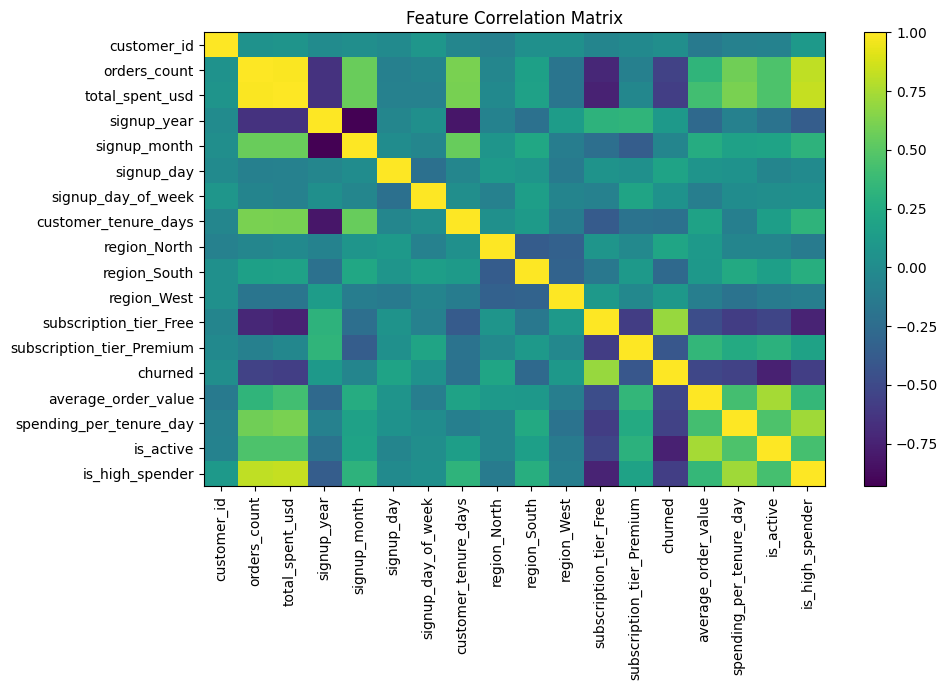

In [364]:
# Plot the correlation matrix

plt.figure(figsize=(10, 7))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.show()

## 12.12 Feature Engineering vs Data Preprocessing

Data Preprocessing and Feature Engineering are related,
but they are not exactly the same.

### Data Preprocessing

The main goal is to clean and transform raw data.

Examples:

- Handling missing values
- Removing duplicates
- Encoding categories
- Scaling features

### Feature Engineering

The main goal is to create or transform features
to represent useful information.

Examples:

- Average order value
- Customer tenure
- Spending per day
- Customer activity
- Ratios
- Aggregations

In practice, the two processes often overlap.

The important idea is:

    Preprocessing → Make data usable

    Feature Engineering → Make features more informative

## 12.13 Final Feature Set

After Feature Engineering, our dataset contains both
original and newly created features.

Some examples are:

### Original Features

- `orders_count`
- `total_spent_usd`
- `signup_year`
- `signup_month`
- `signup_day`
- `signup_day_of_week`
- `customer_tenure_days`

### Encoded Features

- `region_*`
- `subscription_tier_*`

### Engineered Features

- `average_order_value`
- `spending_per_tenure_day`
- `is_active`
- `is_high_spender`

Before training a model, we should carefully decide which
features should actually be included.

We should also make sure that no feature contains information
from the future that would not have been available when the
prediction was made.

This is another important aspect of avoiding **Data Leakage**.

## 12.14 Feature Engineering Observation

In this section, we learned how to create new features
from existing data.

We created:

- `average_order_value`
- `spending_per_tenure_day`
- `is_active`
- `is_high_spender`

We also examined feature correlation.

The key lesson is:

    Better features can help a Machine Learning model
    learn useful patterns more effectively.

However, feature engineering should be performed carefully.

We should avoid:

- Irrelevant features
- Redundant features
- Features based on future information
- Features that cause data leakage

Our next step is one of the most important stages
in the Machine Learning workflow:

    Train-Test Split

# 13. Train-Test Split

Train-Test Split is the process of dividing the available
dataset into separate training and testing datasets.

The training dataset is used to:

- Learn patterns
- Train the Machine Learning model

The testing dataset is used to:

- Evaluate the trained model
- Estimate how well it performs on unseen data

A common split is:

    80% → Training Data
    20% → Testing Data

The basic workflow is:

    Complete Dataset
           ↓
      Train-Test Split
        ↙          ↘
    Training       Testing
       ↓              ↓
    Model Training   Final Evaluation

The test data should remain unseen during model training.

This helps us estimate how the model will perform on
new, unseen customers.

## 13.1 Why Do We Need Train-Test Split?

Suppose we train and evaluate a model using exactly
the same data.

The model has already seen those observations.

Therefore, a high accuracy on that same dataset does not
necessarily mean that the model will perform well on
new customers.

This is similar to giving a student the exact questions
that will appear in an exam before the exam.

The student may memorize the answers without actually
understanding the concepts.

Similarly, a Machine Learning model can memorize patterns
in the training data.

Train-Test Split helps us evaluate generalization.

Generalization means:

    The ability of a model to perform well on unseen data.

In [391]:
# Separate features and target

X = feature_df.drop("churned", axis=1)
y = feature_df["churned"]
# Remove identifier columns
# These columns should not be used for prediction
identifier_columns = [
"customer_id",
"name"
]
X = X.drop(
columns=[
column for column in identifier_columns
if column in X.columns
]
)
# Check the feature columns
print("Features:")
print(X.columns.tolist())

Features:
['orders_count', 'total_spent_usd', 'signup_year', 'signup_month', 'signup_day', 'signup_day_of_week', 'customer_tenure_days', 'region_North', 'region_South', 'region_West', 'subscription_tier_Free', 'subscription_tier_Premium', 'average_order_value', 'spending_per_tenure_day', 'is_active', 'is_high_spender']


In [392]:
# Check for non-numerical columns
non_numeric_columns = X.select_dtypes(
exclude=np.number
).columns.tolist()
print("Non-numerical columns:")
print(non_numeric_columns)

Non-numerical columns:
[]


In [394]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.20,
random_state=42,
stratify=y
)
# Display the shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (40, 16)
X_test : (10, 16)
y_train: (40,)
y_test : (10,)


## 13.3 Understanding `test_size`

The parameter:

    test_size=0.20

means that 20% of the observations are placed into
the testing dataset.

Therefore:

    80% → Training
    20% → Testing

For a larger dataset, an 80/20 split is a common starting point.

Other possible splits include:

    70/30
    75/25
    80/20
    90/10

The appropriate split depends on the size of the dataset
and the Machine Learning problem.

## 13.4 Understanding `random_state`

The `train_test_split()` function randomly divides
the dataset.

Therefore, every execution could produce a different split.

We can use:

    random_state=42

to make the split reproducible.

The number `42` is not special.

Any fixed integer can be used.

For example:

    random_state=0
    random_state=42
    random_state=100

The important point is that we use the same value when
we want reproducible results.